# Prepare the shared COSMOS2020 tutorial catalog

This notebook is the only tutorial that reads the full COSMOS2020 FARMER FITS file.
It applies one documented selection, converts microJy to maggies, chooses 100,000
galaxies and one representative high-S/N object, and writes the compact artifact
used by every inference tutorial.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

REPO_ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "composed").exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from composed.provenance import save_npz_with_provenance

CATALOG_PATH = Path(os.environ.get("COSMOS2020_FARMER_FITS", "~/Downloads/cosmos2020_farmer.fits")).expanduser()
OUTPUT_PATH = REPO_ROOT / "notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz"
N_OBJECTS = 100_000
SEED = 2026

BAND_NAMES = ("u", "g", "r", "i", "z", "Y", "J", "H")
CATALOG_BANDS = ("cfht_u", "hsc_g", "hsc_r", "hsc_i", "hsc_z", "hsc_y", "uvista_j", "uvista_h")
FILTER_NAMES = (
    "cfht_megacam_us_9301", "hsc_g", "hsc_r", "hsc_i", "hsc_z", "hsc_y",
    "vista_vircam_J", "vista_vircam_H",
)
MICROJY_TO_MAGGIES = 10.0 ** (-0.4 * 23.9)


In [2]:
if not CATALOG_PATH.exists():
    raise FileNotFoundError(f"Set COSMOS2020_FARMER_FITS; missing {CATALOG_PATH}")

with fits.open(CATALOG_PATH, memmap=True) as hdul:
    table = hdul[1].data
    selected = np.isfinite(table["lp_zbest"]) & (table["lp_zbest"] > 0.0) & (table["lp_zbest"] < 5.0)
    selected &= np.isfinite(table["lp_mass_med"]) & (table["lp_mass_med"] > 5.0) & (table["lp_mass_med"] < 14.0)
    selected &= (table["lp_type"] == 0) & (table["flag_combined"] == 0)
    for band in CATALOG_BANDS:
        selected &= table[f"{band}_valid"] > 0
        selected &= np.isfinite(table[f"{band}_flux"]) & np.isfinite(table[f"{band}_fluxerr"])
        selected &= table[f"{band}_fluxerr"] > 0.0
    selected &= (table["hsc_r_flux"] / table["hsc_r_fluxerr"] > 5.0) | (table["hsc_i_flux"] / table["hsc_i_fluxerr"] > 5.0)

    eligible = np.flatnonzero(selected)
    if eligible.size < N_OBJECTS:
        raise RuntimeError(f"Selection retained only {eligible.size:,} objects; need {N_OBJECTS:,}.")
    rows = np.sort(np.random.default_rng(SEED).choice(eligible, N_OBJECTS, replace=False))
    flux_ujy = np.column_stack([table[f"{band}_flux"][rows] for band in CATALOG_BANDS]).astype(float)
    sigma_ujy = np.column_stack([table[f"{band}_fluxerr"][rows] for band in CATALOG_BANDS]).astype(float)
    z_ref = np.asarray(table["lp_zbest"][rows], dtype=float)
    mass_ref = np.asarray(table["lp_mass_med"][rows], dtype=float)
    sfr_ref = np.asarray(table["lp_sfr_med"][rows], dtype=float)
    dust_ref = np.asarray(table["lp_dust"][rows], dtype=float)

sfr_ref[(sfr_ref < -10.0) | (sfr_ref > 5.0)] = np.nan
dust_ref[(dust_ref < 0.0) | (dust_ref > 5.0)] = np.nan
min_optical_nir_snr = np.min(flux_ujy[:, 1:] / sigma_ujy[:, 1:], axis=1)
candidate = (z_ref > 0.8) & (z_ref < 1.2) & (mass_ref > 9.5) & (mass_ref < 10.5) & (min_optical_nir_snr > 5.0)
score = ((z_ref - 1.0) / 0.2) ** 2 + ((mass_ref - 10.0) / 0.4) ** 2
candidate_positions = np.flatnonzero(candidate)
if candidate_positions.size == 0:
    candidate_positions = np.flatnonzero(min_optical_nir_snr > 5.0)
if candidate_positions.size == 0:
    raise RuntimeError("No high-S/N object is available for the single-galaxy tutorials.")
single_position = int(candidate_positions[np.argmin(score[candidate_positions])])

flux_maggies = (flux_ujy * MICROJY_TO_MAGGIES).astype(np.float32)
sigma_maggies = (sigma_ujy * MICROJY_TO_MAGGIES).astype(np.float32)
print(f"Eligible: {eligible.size:,}; saved: {len(rows):,}; single position: {single_position}")


Eligible: 636,734; saved: 100,000; single position: 36096


In [3]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_npz_with_provenance(
    OUTPUT_PATH,
    compressed=True,
    provenance_paths={"cosmos2020_farmer": CATALOG_PATH},
    seed=SEED,
    extra={
        "selection": "galaxy, clean, valid ugrizYJH, and S/N_r>5 or S/N_i>5",
        "flux_input_unit": "microJy",
        "flux_output_unit": "maggies",
    },
    row_index=rows.astype(np.int64),
    flux_maggies=flux_maggies,
    sigma_maggies=sigma_maggies,
    lp_zbest=z_ref.astype(np.float32),
    lp_mass_med=mass_ref.astype(np.float32),
    lp_sfr_med=sfr_ref.astype(np.float32),
    lp_dust=dust_ref.astype(np.float32),
    band_names=np.asarray(BAND_NAMES),
    catalog_band_names=np.asarray(CATALOG_BANDS),
    sedpy_filter_names=np.asarray(FILTER_NAMES),
    single_object_position=np.asarray(single_position),
)
print("Wrote", OUTPUT_PATH.relative_to(REPO_ROOT))


Wrote notebooks/tutorials/data/cosmos2020_ugrizYJH_100k.npz


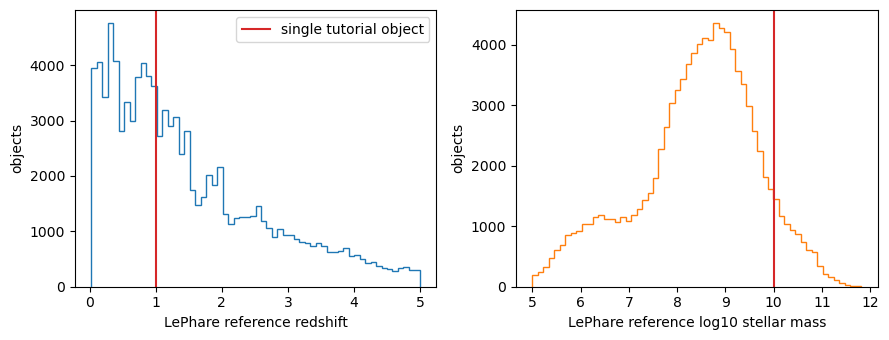

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(z_ref, bins=60, histtype="step", color="C0")
axes[0].axvline(z_ref[single_position], color="C3", label="single tutorial object")
axes[0].set(xlabel="LePhare reference redshift", ylabel="objects")
axes[0].legend()
axes[1].hist(mass_ref, bins=60, histtype="step", color="C1")
axes[1].axvline(mass_ref[single_position], color="C3")
axes[1].set(xlabel="LePhare reference log10 stellar mass", ylabel="objects")
fig.tight_layout()
